# Sales performance: the numbers

This notebook is the source of truth for every number in the README and in the Power BI report. It reads the
client's files from `data/input/` and every client value from `config/client.yaml` (through `config.py`), applies
the rules once, writes the model tables Power BI reads to `output/`, computes each number, draws the charts in
`docs/`, and checks the main totals again with SQL (`sql/checks.sql`).

**Rules** (keys in `config/client.yaml`)

- A sale is an item in an order whose status is in `rules.sale_statuses`.
- Revenue is the item price. Freight is shown on its own. There is no cost in the data, so no margin.
- An order is late when it arrives more than `rules.late_after_days` days after the estimated date (dates only).
- Each order keeps its latest review (the one answered last; on a tie, the higher score).
- Each state's region comes from the regions file (`inputs.regions`).

Run it from the `analysis/` folder: `jupyter nbconvert --to notebook --execute --inplace analysis.ipynb`.

In [1]:
import math
import sys
from pathlib import Path

import duckdb
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from config import check_inputs, load_config

cfg = load_config()
check_inputs(cfg)
NAME, CURRENCY, DECIMALS = cfg["client"]["name"], cfg["client"]["currency"], cfg["client"]["decimals"]
RULES, REPORT, COLOURS = cfg["rules"], cfg["report"], cfg["report"]["colours"]
INPUT, OUTPUT, DOCS = cfg["input_dir"], cfg["output_dir"], ROOT / "docs"
OUTPUT.mkdir(exist_ok=True)
pd.set_option("display.float_format", f"{{:,.{DECIMALS}f}}".format)
print(f"{NAME}: amounts in {CURRENCY}")

Sample marketplace: amounts in BRL


## 1. Load the input files

Each file keeps only its mapped columns, renamed to the standard names (`columns` in `config/client.yaml`).

In [2]:
def read(name, dates=(), numbers=()):
    cols = cfg["columns"][name]
    df = pd.read_csv(INPUT / cfg["inputs"][name], usecols=list(cols.values()), dtype=str, encoding="utf-8-sig")
    df = df.rename(columns={client: standard for standard, client in cols.items()})
    for c in dates:
        df[c] = pd.to_datetime(df[c])
    for c in numbers:
        df[c] = pd.to_numeric(df[c])
    return df


orders = read("orders", dates=["purchased_at", "delivered_at", "estimated_at"])
items = read("items", numbers=["item_no", "price", "freight"])
reviews = read("reviews", dates=["answered_at"], numbers=["score"])
products = read("products")
sellers = read("sellers")
customers = read("customers")
names = read("category_names")
regions = pd.read_csv(INPUT / cfg["inputs"]["regions"], dtype=str)

pd.Series({"orders": len(orders), "items": len(items), "reviews": len(reviews), "products": len(products),
           "sellers": len(sellers), "customers": len(customers)}, name="rows")

orders        99441
items        112650
reviews       99224
products      32951
sellers        3095
customers     99441
Name: rows, dtype: int64

## 2. Health check

Where the data can go wrong, and what the build does about it. Each `assert` stops the notebook with one line
naming the problem.

In [3]:
assert orders["order_id"].is_unique, "orders: order_id is not unique"
assert products["product_id"].is_unique, "products: product_id is not unique"
assert sellers["seller_id"].is_unique, "sellers: seller_id is not unique"
assert customers["customer_id"].is_unique, "customers: customer_id is not unique"
assert not items.duplicated(["order_id", "item_no"]).any(), "items: order_id + item_no is not unique"
assert items["order_id"].isin(orders["order_id"]).all(), "items: an order_id is not in orders"
assert items["product_id"].isin(products["product_id"]).all(), "items: a product_id is not in products"
assert items["seller_id"].isin(sellers["seller_id"]).all(), "items: a seller_id is not in sellers"
assert orders["customer_id"].isin(customers["customer_id"]).all(), "orders: a customer_id is not in customers"
no_region = sorted((set(sellers["state"].dropna()) | set(customers["state"].dropna())) - set(regions["state"]))
assert not no_region, f"data/input/{cfg['inputs']['regions']}: no region for state(s): {', '.join(no_region)}"
assert orders["status"].isin(RULES["sale_statuses"]).any(), "rules.sale_statuses matches no order status"

sale_orders = orders[orders["status"].isin(RULES["sale_statuses"])]
pd.Series({
    "orders that are not a sale (left out)": len(orders) - len(sale_orders),
    "sale orders with no items": (~sale_orders["order_id"].isin(items["order_id"])).sum(),
    "sale orders with no delivery date (kept, not in late %)": sale_orders["delivered_at"].isna().sum(),
    "extra reviews on the same order (latest kept)": reviews["order_id"].duplicated().sum(),
    "reviews answered at the same time on one order (higher score kept)": reviews.duplicated(["order_id", "answered_at"]).sum(),
    "sale orders with no review": (~sale_orders["order_id"].isin(reviews["order_id"])).sum(),
    "products with no category (shown as 'unknown')": products["category"].isna().sum(),
    "categories with no display name (code kept)": len(set(products["category"].dropna()) - set(names["category"])),
}, name="count")

orders that are not a sale (left out)                                 2963
sale orders with no items                                                0
sale orders with no delivery date (kept, not in late %)                  8
extra reviews on the same order (latest kept)                          551
reviews answered at the same time on one order (higher score kept)       0
sale orders with no review                                             646
products with no category (shown as 'unknown')                         610
categories with no display name (code kept)                              2
Name: count, dtype: int64

In [4]:
orders["status"].value_counts()

status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

## 3. Build the model tables and write them for Power BI

One fact table at order-item grain and three dimensions, written to `output/` (Power BI reads these files; the
date dimension is built in DAX, `powerbi/02-model.md`). `report_settings.csv` carries the top-N values to DAX.

In [5]:
REGION_OF = dict(zip(regions["state"], regions["region"]))

o = sale_orders[["order_id", "customer_id"]].copy()
o["order_date"] = sale_orders["purchased_at"].dt.normalize()
delivered_date = sale_orders["delivered_at"].dt.normalize()
estimated_date = sale_orders["estimated_at"].dt.normalize()
o["delivery_days"] = (delivered_date - o["order_date"]).dt.days.astype("Int64")
o["delivery_status"] = "On time"
o.loc[delivered_date > estimated_date + pd.Timedelta(days=RULES["late_after_days"]), "delivery_status"] = "Late"
o.loc[delivered_date.isna(), "delivery_status"] = "No date"

latest_review = (reviews.sort_values(["answered_at", "score"])
                 .drop_duplicates("order_id", keep="last")[["order_id", "score"]]
                 .rename(columns={"score": "review_score"}))

fact_sales = (items.merge(o, on="order_id")
              .merge(latest_review, on="order_id", how="left")
              [["order_id", "item_no", "order_date", "product_id", "seller_id", "customer_id",
                "price", "freight", "delivery_days", "delivery_status", "review_score"]])
fact_sales["review_score"] = fact_sales["review_score"].astype("Int64")

dim_product = products.merge(names, on="category", how="left")
dim_product["category"] = (dim_product["name"].fillna(dim_product["category"]).fillna("unknown")
                           .str.replace("_", " "))
dim_product = dim_product[["product_id", "category"]]

dim_seller = sellers.rename(columns={"city": "seller_city", "state": "seller_state"})
dim_seller["seller_region"] = dim_seller["seller_state"].map(REGION_OF)
dim_seller["seller_short_id"] = dim_seller["seller_id"].str[:8]

dim_customer = customers.rename(columns={"city": "customer_city", "state": "customer_state"})
dim_customer["customer_region"] = dim_customer["customer_state"].map(REGION_OF)

assert not fact_sales.duplicated(["order_id", "item_no"]).any()
assert dim_seller["seller_short_id"].is_unique, "sellers: two seller ids share their first 8 characters"

fact_sales.to_csv(OUTPUT / "fact_sales.csv", index=False, date_format="%Y-%m-%d")
dim_product.to_csv(OUTPUT / "dim_product.csv", index=False)
dim_seller.to_csv(OUTPUT / "dim_seller.csv", index=False)
dim_customer.to_csv(OUTPUT / "dim_customer.csv", index=False)
pd.DataFrame([{"top_categories": REPORT["top_categories"],
               "top_sellers_percent": REPORT["top_sellers_percent"]}]).to_csv(OUTPUT / "report_settings.csv", index=False)

pd.Series({"fact_sales": len(fact_sales), "dim_product": len(dim_product), "dim_seller": len(dim_seller),
           "dim_customer": len(dim_customer)}, name="rows written to output/")

fact_sales      110197
dim_product      32951
dim_seller        3095
dim_customer     99441
Name: rows written to output/, dtype: int64

## 4. Headline numbers (Overview page)

Order-level numbers (delivery, reviews) are counted once per order, not once per item.

In [6]:
per_order = fact_sales.drop_duplicates("order_id").merge(dim_customer, on="customer_id")
dated = per_order[per_order["delivery_status"] != "No date"]

revenue = fact_sales["price"].sum()
freight = fact_sales["freight"].sum()
n_orders = fact_sales["order_id"].nunique()
n_customers = per_order["person_id"].nunique()
late_share = (dated["delivery_status"] == "Late").mean()

kpi = pd.Series({
    "Revenue": revenue,
    "Orders": n_orders,
    "Items sold": len(fact_sales),
    "Average order value": revenue / n_orders,
    "Customers": n_customers,
    "Freight": freight,
    "Freight % of revenue": freight / revenue * 100,
    "Late deliveries %": late_share * 100,
    "Late orders": (dated["delivery_status"] == "Late").sum(),
    "Average delivery days": dated["delivery_days"].mean(),
    "Average review": per_order["review_score"].mean(),
})
kpi

Revenue                 13,221,498.11
Orders                      96,478.00
Items sold                 110,197.00
Average order value            137.04
Customers                   93,358.00
Freight                  2,198,275.64
Freight % of revenue            16.63
Late deliveries %                6.77
Late orders                  6,534.00
Average delivery days           12.50
Average review                   4.16
dtype: float64

## 5. Growth against last year (Sales page)

`report.compare_year` is compared with the same days of the year before: up to the last order date when the data
stops inside that year, the whole year otherwise.

In [7]:
CY = REPORT["compare_year"]
last_day = fact_sales["order_date"].max()
end = min(last_day, pd.Timestamp(CY, 12, 31))
end_last_year = end - pd.DateOffset(years=1)
sales_cy = fact_sales[fact_sales["order_date"].between(pd.Timestamp(CY, 1, 1), end)]
rev_cy = sales_cy["price"].sum()
orders_cy = sales_cy["order_id"].nunique()
rev_ly = fact_sales.loc[fact_sales["order_date"].between(pd.Timestamp(CY - 1, 1, 1), end_last_year), "price"].sum()
growth = rev_cy / rev_ly - 1

orders_per_customer = per_order.groupby("person_id")["order_id"].nunique()
repeat_share = (orders_per_customer >= 2).mean()

pd.Series({
    "Compared": f"1 Jan to {end:%d %b} of {CY} against {CY - 1}",
    f"Revenue {CY}": rev_cy,
    f"Revenue {CY - 1}, same days": rev_ly,
    "Growth %": growth * 100,
    f"Orders {CY}": orders_cy,
    f"Average order value {CY}": rev_cy / orders_cy,
    f"Freight % of revenue {CY}": sales_cy["freight"].sum() / rev_cy * 100,
    "Customers with 2+ orders %": repeat_share * 100,
}, dtype=object)

Compared                      1 Jan to 29 Aug of 2018 against 2017
Revenue 2018                                          7,218,125.12
Revenue 2017, same days                               2,944,431.50
Growth %                                                    145.14
Orders 2018                                                  52783
Average order value 2018                                    136.75
Freight % of revenue 2018                                    17.09
Customers with 2+ orders %                                    3.00
dtype: object

In [8]:
monthly = (fact_sales.assign(month=fact_sales["order_date"].dt.to_period("M"))
           .groupby("month").agg(revenue=("price", "sum"), orders=("order_id", "nunique")))
monthly["average_order_value"] = monthly["revenue"] / monthly["orders"]
monthly.loc[f"{CY - 1}-01":]

,revenue,orders,average_order_value
month,,,
2017-01,"111,798.36",750,149.06
2017-02,"234,223.40",1653,141.70
2017-03,"359,198.85",2546,141.08
2017-04,"340,669.68",2303,147.92
2017-05,"489,338.25",3546,138.00
2017-06,"421,923.37",3135,134.58
2017-07,"481,604.52",3872,124.38
2017-08,"554,699.70",4193,132.29
2017-09,"607,399.67",4150,146.36


## 6. Delivery and reviews (Delivery page)

In [9]:
by_status = (per_order[per_order["delivery_status"] != "No date"]
             .groupby("delivery_status")
             .agg(orders=("order_id", "count"),
                  average_review=("review_score", "mean"),
                  one_or_two_stars_pct=("review_score", lambda s: (s <= 2).sum() / s.notna().sum() * 100),
                  average_delivery_days=("delivery_days", "mean")))
by_status

,orders,average_review,one_or_two_stars_pct,average_delivery_days
delivery_status,,,,
Late,6534,2.27,62.42,33.91
On time,89936,4.29,9.27,10.94


In [10]:
late_by_state = (dated.groupby("customer_state")
                 .agg(orders=("order_id", "count"), late_pct=("delivery_status", lambda s: (s == "Late").mean() * 100))
                 .sort_values("late_pct", ascending=False))
late_by_state.head(5)

,orders,late_pct
customer_state,,
AL,397,21.41
MA,717,17.43
SE,335,15.22
PI,476,13.87
CE,1279,13.76


## 7. Categories (Categories page)

In [11]:
TOP_N = REPORT["top_categories"]
by_category = (fact_sales.merge(dim_product, on="product_id")
               .groupby("category")
               .agg(revenue=("price", "sum"), items=("item_no", "count"))
               .sort_values("revenue", ascending=False))
by_category["share_pct"] = by_category["revenue"] / revenue * 100
top_category_share = by_category["revenue"].head(TOP_N).sum() / revenue

print(f"Categories with sales: {len(by_category)}")
print(f"Top {TOP_N} categories: {top_category_share:.1%} of revenue")
by_category.head(TOP_N)

Categories with sales: 74
Top 10 categories: 62.4% of revenue


,revenue,items,share_pct
category,,,
health beauty,"1,233,131.72",9465,9.33
watches gifts,"1,166,176.98",5859,8.82
bed bath table,"1,023,434.76",10953,7.74
sports leisure,"954,852.55",8431,7.22
computers accessories,"888,724.61",7644,6.72
furniture decor,"711,927.69",8160,5.38
housewares,"615,628.69",6795,4.66
cool stuff,"610,204.10",3718,4.62
auto,"578,966.65",4140,4.38


## 8. Sellers (Sellers page)

The top sellers are the first `ceil(sellers with sales x report.top_sellers_percent / 100)` sellers by revenue,
the same rule as the DAX measure `Top Sellers Share`.

In [12]:
PCT = REPORT["top_sellers_percent"]
by_seller = fact_sales.groupby("seller_id")["price"].sum().sort_values(ascending=False)
n_sellers = len(by_seller)
n_top = math.ceil(n_sellers * PCT / 100)
top_seller_share = by_seller.head(n_top).sum() / revenue
top_seller = by_seller.index[0]

print(f"Sellers with sales: {n_sellers}; top {PCT}% = {n_top} sellers")
print(f"Top {PCT}% of sellers: {top_seller_share:.1%} of revenue")
print(f"Largest seller: {top_seller[:8]} with {by_seller.iloc[0]:,.{DECIMALS}f}")

Sellers with sales: 2970; top 10% = 297 sellers
Top 10% of sellers: 67.1% of revenue
Largest seller: 4869f7a5 with 226,987.93


## 9. Regions (row-level security check)

Each security role shows only one seller region. These are the revenue totals each role must see.

In [13]:
by_seller_region = (fact_sales.merge(dim_seller, on="seller_id")
                    .groupby("seller_region")["price"].sum().sort_values(ascending=False))
by_customer_region = (fact_sales.merge(dim_customer, on="customer_id")
                      .groupby("customer_region")["price"].sum().sort_values(ascending=False))
pd.DataFrame({"revenue by seller region": by_seller_region, "revenue by customer region": by_customer_region})

,revenue by seller region,revenue by customer region
Southeast,"10,354,931.00","8,648,409.57"
South,"2,219,100.72","1,901,973.11"
Northeast,"455,082.78","1,497,083.78"
Center-West,"185,206.41","846,956.70"
North,"7,177.20","327,074.95"


## 10. Charts for the README

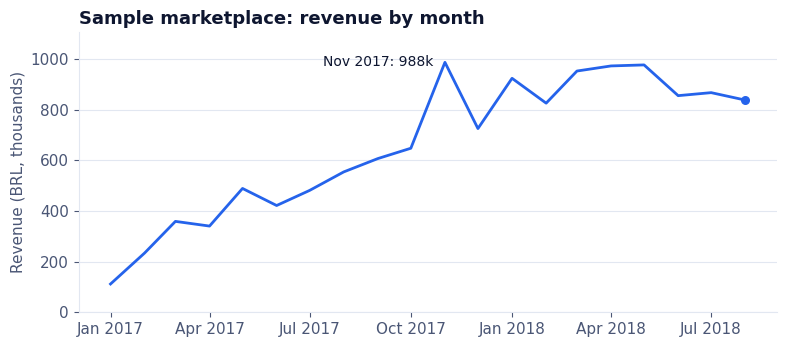

In [14]:
MAIN, DANGER, TEXT, MUTED, LINE = (COLOURS["data"][0], COLOURS["danger"], COLOURS["text"],
                                   COLOURS["muted"], COLOURS["line"])
plt.rcParams.update({
    "font.size": 11, "text.color": TEXT, "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": LINE, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": LINE, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "figure.facecolor": "white", "savefig.facecolor": "white", "savefig.dpi": 150,
})

# Revenue by month, from January of the year before the compare year
m = monthly.loc[f"{CY - 1}-01":]
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(m.index.to_timestamp(), m["revenue"] / 1e3, color=MAIN, linewidth=2)
ax.scatter(m.index[-1].to_timestamp(), m["revenue"].iloc[-1] / 1e3, color=MAIN, s=30, zorder=3)
peak = m["revenue"].idxmax()
ax.annotate(f"{peak.strftime('%b %Y')}: {m['revenue'].max() / 1e3:,.0f}k", (peak.to_timestamp(), m["revenue"].max() / 1e3),
            xytext=(-8, 0), textcoords="offset points", ha="right", va="center", fontsize=10)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_ylabel(f"Revenue ({CURRENCY}, thousands)")
ax.set_ylim(0, m["revenue"].max() / 1e3 * 1.12)
ax.grid(axis="x", visible=False)
ax.set_title(f"{NAME}: revenue by month", loc="left", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(DOCS / "revenue-by-month.png")
plt.show()

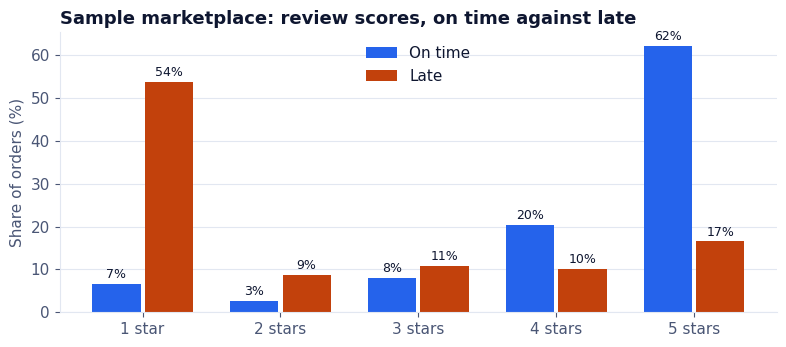

In [15]:
# Review scores: on time against late (share of reviewed orders at each score)
reviewed = per_order[per_order["review_score"].notna() & (per_order["delivery_status"] != "No date")]
dist = (pd.crosstab(reviewed["review_score"].astype(int), reviewed["delivery_status"], normalize="columns") * 100)
dist = dist.reindex(index=range(1, 6), columns=["On time", "Late"], fill_value=0)

fig, ax = plt.subplots(figsize=(8, 3.6))
width = 0.38
for offset, status, color in [(-width / 2, "On time", MAIN), (width / 2, "Late", DANGER)]:
    bars = ax.bar(dist.index + offset, dist[status], width=width - 0.03, color=color, label=status)
    ax.bar_label(bars, fmt="%.0f%%", fontsize=9, color=TEXT, padding=2)
ax.set_xticks(dist.index, [f"{s} star" + ("s" if s > 1 else "") for s in dist.index])
ax.set_ylabel("Share of orders (%)")
ax.grid(axis="x", visible=False)
ax.legend(frameon=False, loc="upper center")
ax.set_title(f"{NAME}: review scores, on time against late", loc="left", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(DOCS / "reviews-on-time-vs-late.png")
plt.show()

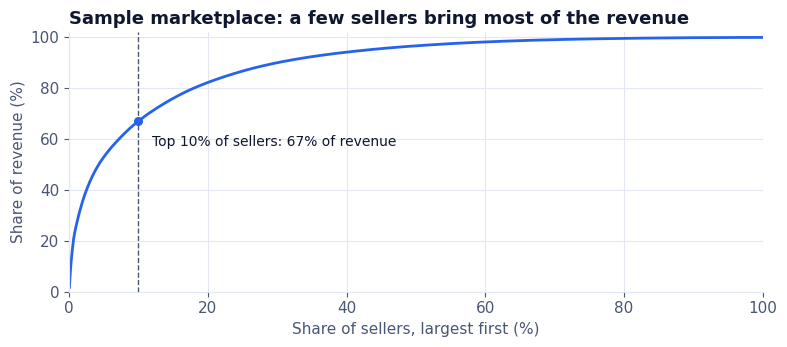

In [16]:
# Seller concentration: cumulative share of revenue against share of sellers
cum = by_seller.cumsum() / revenue * 100
x = pd.Series(range(1, n_sellers + 1)) / n_sellers * 100

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(x, cum.values, color=MAIN, linewidth=2)
ax.axvline(PCT, color=MUTED, linewidth=1, linestyle="--")
ax.scatter([n_top / n_sellers * 100], [top_seller_share * 100], color=MAIN, s=30, zorder=3)
ax.annotate(f"Top {PCT}% of sellers: {top_seller_share:.0%} of revenue", (n_top / n_sellers * 100, top_seller_share * 100),
            xytext=(10, -18), textcoords="offset points", fontsize=10)
ax.set_xlabel("Share of sellers, largest first (%)")
ax.set_ylabel("Share of revenue (%)")
ax.set_xlim(0, 100)
ax.set_ylim(0, 102)
ax.set_title(f"{NAME}: a few sellers bring most of the revenue", loc="left", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(DOCS / "seller-concentration.png")
plt.show()

## 11. Check the totals again with SQL

`sql/checks.sql` computes the main totals with DuckDB straight from the input files, apart from the pandas code
above. The views give the files their standard column names; the rules arrive as parameters. Every value must
match the notebook.

In [17]:
con = duckdb.connect()
for name in ["orders", "items", "reviews", "customers"]:
    path = (INPUT / cfg["inputs"][name]).as_posix()
    select = ", ".join(f'"{client}" AS {standard}' for standard, client in cfg["columns"][name].items())
    con.execute(f"CREATE VIEW {name} AS SELECT {select} FROM read_csv('{path}')")
params = {"sale_statuses": RULES["sale_statuses"], "late_after_days": RULES["late_after_days"], "compare_year": CY}
sql = con.execute((ROOT / "sql" / "checks.sql").read_text(), params).df().iloc[0]

pairs = {
    "revenue": revenue,
    "orders": n_orders,
    "customers": n_customers,
    "late_pct": late_share * 100,
    "avg_review": kpi["Average review"],
    "growth_pct": growth * 100,
}
check = pd.DataFrame({"notebook": pairs, "sql": {k: sql[k] for k in pairs}})
check["match"] = [math.isclose(a, b, rel_tol=1e-9) for a, b in zip(check["notebook"], check["sql"])]
assert check["match"].all(), check
check

,notebook,sql,match
revenue,"13,221,498.11","13,221,498.11",True
orders,"96,478.00","96,478.00",True
customers,"93,358.00","93,358.00",True
late_pct,6.77,6.77,True
avg_review,4.16,4.16,True
growth_pct,145.14,145.14,True


## 12. Numbers for `powerbi/06-checks.md` and the README

In [18]:
amount = lambda x: f"{x:,.{DECIMALS}f}"
summary = pd.Series({
    "Currency": CURRENCY,
    "Revenue": amount(revenue),
    "Orders": f"{n_orders:,}",
    "Items sold": f"{len(fact_sales):,}",
    "Average order value": amount(revenue / n_orders),
    "Customers": f"{n_customers:,}",
    "Freight % of revenue": f"{freight / revenue:.1%}",
    "Late deliveries %": f"{late_share:.1%}",
    "Late orders": f"{kpi['Late orders']:,.0f}",
    "Average delivery days": f"{kpi['Average delivery days']:.1f}",
    "Average review": f"{kpi['Average review']:.2f}",
    "Average review, on time": f"{by_status.loc['On time', 'average_review']:.2f}",
    "Average review, late": f"{by_status.loc['Late', 'average_review']:.2f}",
    "1-2 stars, on time": f"{by_status.loc['On time', 'one_or_two_stars_pct']:.1f}%",
    "1-2 stars, late": f"{by_status.loc['Late', 'one_or_two_stars_pct']:.1f}%",
    "1 star, on time": f"{dist.loc[1, 'On time']:.1f}%",
    "1 star, late": f"{dist.loc[1, 'Late']:.1f}%",
    "Highest late % state": f"{late_by_state.index[0]} ({late_by_state['late_pct'].iloc[0]:.1f}%)",
    "Customers with 2+ orders %": f"{repeat_share:.1%}",
    f"{CY}: revenue": amount(rev_cy),
    f"{CY}: revenue last year (same days of {CY - 1})": amount(rev_ly),
    f"{CY}: revenue vs last year %": f"{growth:.1%}",
    f"{CY}: orders": f"{orders_cy:,}",
    f"{CY}: average order value": amount(rev_cy / orders_cy),
    f"{CY}: freight % of revenue": f"{sales_cy['freight'].sum() / rev_cy:.1%}",
    "Categories with sales": f"{len(by_category)}",
    "Top category": f"{by_category.index[0]} ({amount(by_category['revenue'].iloc[0])})",
    f"Top {TOP_N} categories share": f"{top_category_share:.1%}",
    "Sellers with sales": f"{n_sellers:,}",
    f"Top {PCT}% sellers share": f"{top_seller_share:.1%} ({n_top} sellers)",
    "Largest seller": f"{top_seller[:8]} ({amount(by_seller.iloc[0])})",
    **{f"Role {r}: revenue": amount(v) for r, v in by_seller_region.items()},
}, name="value")
summary

Currency                                                                BRL
Revenue                                                       13,221,498.11
Orders                                                               96,478
Items sold                                                          110,197
Average order value                                                  137.04
Customers                                                            93,358
Freight % of revenue                                                  16.6%
Late deliveries %                                                      6.8%
Late orders                                                           6,534
Average delivery days                                                  12.5
Average review                                                         4.16
Average review, on time                                                4.29
Average review, late                                                   2.27
1-2 stars, o